# Project 1: The Sequence Inversion Engine (Encoder-Only Transformer)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [2]:
# Configuration
seq_len = 8          # Length of each number sequence
vocab_size = 20      # Digits 1 to 19 (0 reserved for padding if needed)
num_samples = 3000   # Dataset size

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# Generate random sequences of integers between 1 and vocab_size - 1
x_data = np.random.randint(1, vocab_size, size=(num_samples,seq_len))
# Target is simply the flipped sequence along the time axis
y_data = np.flip(x_data, axis=1)

In [4]:
# Split data into training and validation set
split = int(0.85 * num_samples)
x_train, x_val = x_data[:split], x_data[split:]
y_train, y_val = y_data[:split],y_data[split:]

In [5]:
print("Sample Input: ", x_train[0])
print("Sample Target:", y_train[0])
print(f"Train shape: {x_train.shape}, Val shape: {x_val.shape}")

Sample Input:  [ 7 15 11  8  7 19 11 11]
Sample Target: [11 11 19  7  8 11 15  7]
Train shape: (2550, 8), Val shape: (450, 8)


In [6]:
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, seq_len, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=embed_dim)
        self.seq_len = seq_len

    def call(self, x):
        length = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        positions = self.pos_emb(positions)
        tokens = self.token_emb(x)
        return tokens + positions 

In [7]:
class TransformerEncoderBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, 
            key_dim=d_model // num_heads
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(d_ff, activation="relu"),
            tf.keras.layers.Dense(d_model)
        ])
        self.ln1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, inputs, training=False, return_attention=False):
        attn_out, scores = self.mha(
            query=inputs, 
            value=inputs, 
            key=inputs, 
            return_attention_scores=True
        )
        attn_out = self.dropout1(attn_out, training=training)
        out1 = self.ln1(inputs + attn_out)
        
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out, training=training)
        out2 = self.ln2(out1 + ffn_out)
        
        if return_attention:
            return out2, scores
        return out2

In [8]:
embed_dim = 32
num_heads = 4
d_ff = 64

inputs = tf.keras.layers.Input(shape=(seq_len,), dtype=tf.int32, name="input_sequence")

# 1. Embed tokens + positions
x = PositionalEmbedding(seq_len=seq_len, vocab_size=vocab_size, embed_dim=embed_dim)(inputs)

# 2. Transformer Block
encoder_layer = TransformerEncoderBlock(d_model=embed_dim, num_heads=num_heads, d_ff=d_ff)
x = encoder_layer(x)

# 3. Dense classification head applied per timestep
outputs = tf.keras.layers.Dense(vocab_size, activation="softmax")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [14]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

In [15]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)          │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ positional_embedding                 │ (None, 8, 32)               │             896 │
│ (PositionalEmbedding)                │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_block            │ (None, 8, 32)               │           8,544 │
│ (TransformerEncoderBlock)            │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8, 20)               │             660 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,100 (39.45 KB)

 Trainable params: 10,100 (39.45 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    x_train,y_train,
    validation_data=(x_val,y_val),
    epochs=20,
    batch_size=64
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1375 - loss: 2.7981 - val_accuracy: 0.2253 - val_loss: 2.4898
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2721 - loss: 2.2568 - val_accuracy: 0.4936 - val_loss: 1.5472
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8221 - loss: 0.6149 - val_accuracy: 1.0000 - val_loss: 0.0124
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9999 - loss: 0.0090 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 8.7166e-04
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 6.6508e-04
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - 

In [17]:
# Generate 3 completely new test sequences
test_samples = np.array([
    [1, 2, 3, 4, 5, 6, 7, 8],
    [19, 15, 11, 7, 3, 2, 1, 9],
    [5, 5, 12, 12, 8, 8, 1, 1]
])

preds = model.predict(test_samples)
pred_sequences = np.argmax(preds, axis=-1)

for orig, pred in zip(test_samples, pred_sequences):
    print(f"Original : {orig.tolist()}")
    print(f"Reversed : {pred.tolist()}")
    print(f"Correct? : {np.array_equal(np.flip(orig), pred)}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
Original : [1, 2, 3, 4, 5, 6, 7, 8]
Reversed : [8, 7, 6, 5, 4, 3, 2, 1]
Correct? : True

Original : [19, 15, 11, 7, 3, 2, 1, 9]
Reversed : [9, 1, 2, 3, 7, 11, 15, 19]
Correct? : True

Original : [5, 5, 12, 12, 8, 8, 1, 1]
Reversed : [1, 1, 8, 8, 12, 12, 5, 5]
Correct? : True



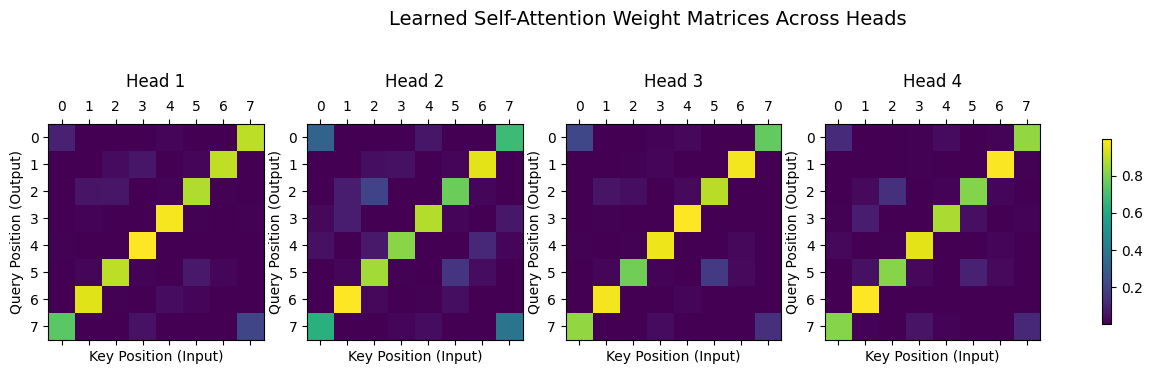

In [18]:
# Extract attention scores for the first test sample
sample = test_samples[0:1] # shape (1, 8)

# Forward pass through embedding layer
emb_out = model.get_layer("positional_embedding")(sample)

# Call the transformer block directly with return_attention=True
_, attention_scores = encoder_layer(emb_out, return_attention=True)
# attention_scores shape: (batch_size, num_heads, seq_len, seq_len)
attn_map = attention_scores.numpy()[0] # shape (4, 8, 8)

# Plot each of the 4 attention heads
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for head in range(4):
    ax = axes[head]
    cax = ax.matshow(attn_map[head], cmap='viridis')
    ax.set_title(f"Head {head + 1}", pad=10)
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xlabel("Key Position (Input)")
    ax.set_ylabel("Query Position (Output)")

fig.colorbar(cax, ax=axes.ravel().tolist(), shrink=0.6)
plt.suptitle("Learned Self-Attention Weight Matrices Across Heads", fontsize=14, y=1.05)
plt.show()